In [3]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [4]:
heart_df = pd.read_csv("/content/heart.csv")

In [5]:
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [6]:
heart_df.sample(5)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
628,61,M,TA,134,234,0,Normal,145,N,2.6,Flat,1
525,45,M,NAP,130,236,0,Normal,144,N,0.1,Up,0
847,45,M,ASY,115,260,0,LVH,185,N,0.0,Up,0
52,45,M,ATA,140,224,1,Normal,122,N,0.0,Up,0
216,39,M,ASY,110,280,0,Normal,150,N,0.0,Flat,1


In [7]:
heart_df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [8]:
heart_df.describe(include = "all")

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,918.000000,918,918,918.000000,918.000000,918.000000,918,918.000000,918,918.000000,918,918.000000
unique,NaN,2,4,NaN,NaN,NaN,3,NaN,2,NaN,3,NaN
top,NaN,M,ASY,NaN,NaN,NaN,Normal,NaN,N,NaN,Flat,NaN
freq,NaN,725,496,NaN,NaN,NaN,552,NaN,547,NaN,460,NaN
mean,53.510893,NaN,NaN,132.396514,198.799564,0.233115,NaN,136.809368,NaN,0.887364,NaN,0.553377
std,9.432617,NaN,NaN,18.514154,109.384145,0.423046,NaN,25.460334,NaN,1.066570,NaN,0.497414
min,28.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN,60.000000,NaN,-2.600000,NaN,0.000000
25%,47.000000,NaN,NaN,120.000000,173.250000,0.000000,NaN,120.000000,NaN,0.000000,NaN,0.000000
50%,54.000000,NaN,NaN,130.000000,223.000000,0.000000,NaN,138.000000,NaN,0.600000,NaN,1.000000
75%,60.000000,NaN,NaN,140.000000,267.000000,0.000000,NaN,156.000000,NaN,1.500000,NaN,1.000000


In [9]:
heart_df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [10]:
heart_df.duplicated().sum()

np.int64(0)

In [11]:
heart_df.nunique()

,0
Age,50
Sex,2
ChestPainType,4
RestingBP,67
Cholesterol,222
FastingBS,2
RestingECG,3
MaxHR,119
ExerciseAngina,2
Oldpeak,53


In [12]:
heart_df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [13]:
heart_df.select_dtypes(include = "object").columns

Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')

In [14]:
cat_col = heart_df.select_dtypes(include = "object").columns

In [15]:
for col in cat_col:
  print(col)

Sex
ChestPainType
RestingECG
ExerciseAngina
ST_Slope


In [16]:
heart_df['ChestPainType'].unique()

array(['ATA', 'NAP', 'ASY', 'TA'], dtype=object)

In [17]:
heart_df["ChestPainType"].nunique()

4

In [18]:
for col in cat_col:
  print(col)
  print((heart_df[col].unique()),list(range(heart_df[col].nunique())))
  heart_df[col].replace((heart_df[col].unique()),range(heart_df[col].nunique()),inplace = True)
  print("*" *50)
  print()

Sex
['M' 'F'] [0, 1]
**************************************************

ChestPainType
['ATA' 'NAP' 'ASY' 'TA'] [0, 1, 2, 3]
**************************************************

RestingECG
['Normal' 'ST' 'LVH'] [0, 1, 2]
**************************************************

ExerciseAngina
['N' 'Y'] [0, 1]
**************************************************

ST_Slope
['Up' 'Flat' 'Down'] [0, 1, 2]
**************************************************



In [19]:
heart_df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,0,140,289,0,0,172,0,0.0,0,0
1,49,1,1,160,180,0,0,156,0,1.0,1,1
2,37,0,0,130,283,0,1,98,0,0.0,0,0
3,48,1,2,138,214,0,0,108,1,1.5,1,1
4,54,0,1,150,195,0,0,122,0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,0,3,110,264,0,0,132,0,1.2,1,1
914,68,0,2,144,193,1,0,141,0,3.4,1,1
915,57,0,2,130,131,0,0,115,1,1.2,1,1
916,57,1,0,130,236,0,2,174,0,0.0,1,1


In [20]:
np.nan

nan

In [21]:
heart_df['Cholesterol'].replace(0,np.nan,inplace=True)

In [22]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors = 3)
after_imputer = imputer.fit_transform(heart_df)
heart_df = pd.DataFrame(after_imputer,columns=heart_df.columns)


In [23]:
heart_df['Cholesterol'].isna().sum()

np.int64(0)

In [24]:
count = 0
for i in heart_df['Cholesterol']:
  if i==0:
    count += 1
print(count)

0


In [25]:
heart_df['RestingBP'][heart_df['RestingBP'] == 0]

,RestingBP
449,0.0


In [26]:
heart_df['RestingBP'].unique()

array([140., 160., 130., 138., 150., 120., 110., 136., 115., 100., 124.,
       113., 125., 145., 112., 132., 118., 170., 142., 190., 135., 180.,
       108., 155., 128., 106.,  92., 200., 122.,  98., 105., 133.,  95.,
        80., 137., 185., 165., 126., 152., 116.,   0., 144., 154., 134.,
       104., 139., 131., 141., 178., 146., 158., 123., 102.,  96., 143.,
       172., 156., 114., 127., 101., 174.,  94., 148., 117., 192., 129.,
       164.])

In [27]:
heart_df['RestingBP'].isnull().sum()

np.int64(0)

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

from xgboost import XGBClassifier

In [30]:
df = pd.read_csv("heart.csv")

Encoding categorical columns

In [31]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = LabelEncoder().fit_transform(df[col])


Spliting features & target

In [33]:
X = df.drop(columns=['HeartDisease'])
y = df['HeartDisease']

Train-test split


In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Random Forest Model

In [36]:
rf = RandomForestClassifier(n_estimators=30, max_depth=5, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)


XGBoost Model

In [37]:
xgb = XGBClassifier(n_estimators=30, max_depth=3, learning_rate=0.1, eval_metric='logloss')
xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_preds)

Accuracy Comparison Plot

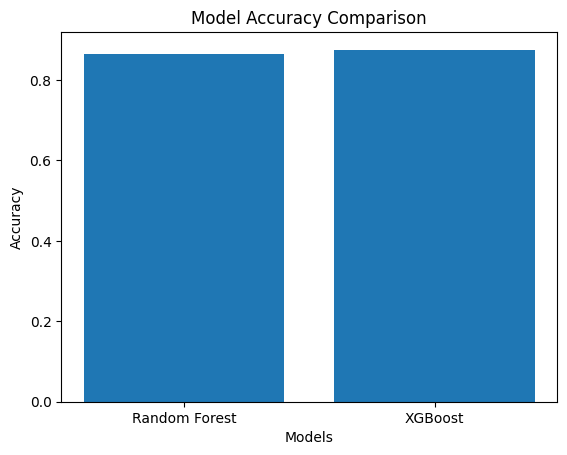

In [39]:
models = ['Random Forest', 'XGBoost']
accuracies = [rf_acc, xgb_acc]
plt.figure()
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

Confusion Matrix - RF

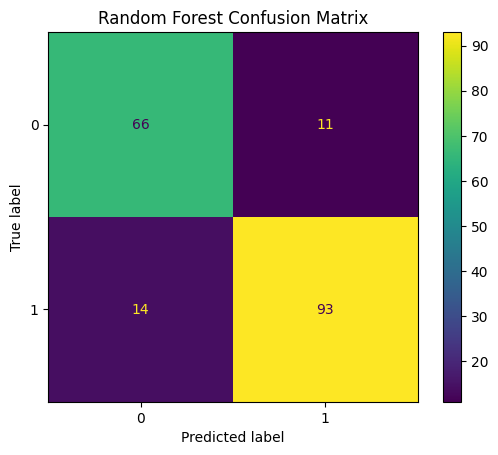

In [40]:
ConfusionMatrixDisplay.from_predictions(y_test, rf_preds)
plt.title("Random Forest Confusion Matrix")
plt.show()

Confusion Matrix - XGB

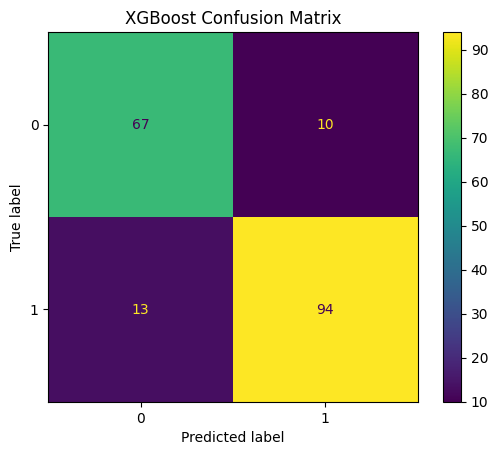

In [41]:
ConfusionMatrixDisplay.from_predictions(y_test, xgb_preds)
plt.title("XGBoost Confusion Matrix")
plt.show()

Feature Importance (RF)

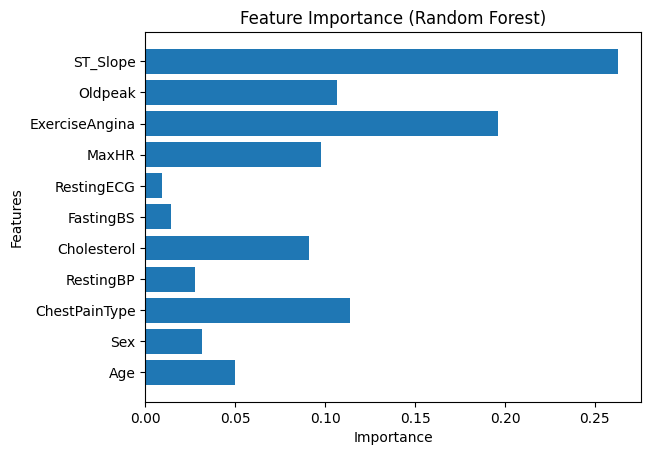

In [42]:
importances = rf.feature_importances_

plt.figure()
plt.barh(X.columns, importances)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

Print Accuracy

In [43]:
print("Random Forest Accuracy:", rf_acc)
print("XGBoost Accuracy:", xgb_acc)

Random Forest Accuracy: 0.8641304347826086
XGBoost Accuracy: 0.875
